# Final Project: League of Legends Match Predictor

**Objective:** Build a logistic regression model in PyTorch to predict the outcome
(win/loss for the Blue team) of ranked League of Legends matches, using
early-game (10-minute mark) team statistics.

This notebook covers, in order:

1. Data loading & preprocessing
2. Logistic regression model definition (PyTorch)
3. Model training
4. Optimization (L2 regularization) & performance evaluation
5. Visualization: confusion matrix & ROC curve
6. Saving & loading the trained model
7. Hyperparameter tuning (learning rate search)
8. Feature importance analysis


## Step 1.1 — Load and Preprocess the Dataset

We load the `league_of_legends_data_stats.csv` dataset, which contains
early-game (10-minute) statistics for the Blue and Red teams in ranked
matches, along with the match outcome (`blueWins`: 1 = Blue team won,
0 = Blue team lost).

Preprocessing steps:
- Separate features (`X`) from the target (`y`, i.e. `blueWins`).
- Split into train/test sets (80/20), stratified on the target.
- Standardize features with `StandardScaler` (zero mean, unit variance) —
  important for gradient-descent-based optimization to converge well.
- Convert the resulting NumPy arrays into PyTorch tensors.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# Load dataset
df = pd.read_csv("league_of_legends_data_stats.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9879, 37)


,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,...,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redCSPerMin,redGoldPerMin
0,0,28,1,0,6,3,9,1,0,0,...,1,0,0,16382,7.12,17736,256,64,25.6,1638.2
1,0,28,1,1,4,9,6,1,0,0,...,1,0,2,19327,6.50,18795,194,74,19.4,1932.7
2,1,23,2,1,4,7,8,0,0,0,...,0,0,0,14939,6.50,18645,229,46,22.9,1493.9
3,1,19,5,1,9,5,8,0,1,0,...,0,1,0,13777,6.94,15089,201,42,20.1,1377.7
4,0,15,0,0,0,15,1,0,0,0,...,0,0,1,18956,7.06,18179,264,72,26.4,1895.6


In [2]:
# Separate features and target
X = df.drop(columns=["blueWins"])
y = df["blueWins"]

feature_names = X.columns.tolist()
print(f"Number of features: {len(feature_names)}")

# Train/test split (80/20), stratified on target to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (fit on train, apply to both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

Number of features: 36
X_train_tensor: torch.Size([7903, 36])
y_train_tensor: torch.Size([7903, 1])
X_test_tensor: torch.Size([1976, 36])
y_test_tensor: torch.Size([1976, 1])


## Step 1.2 — Implement a Logistic Regression Model in PyTorch

Logistic regression is implemented as a single linear layer
(`nn.Linear(input_dim, 1)`) followed by a sigmoid activation, which squashes
the output into a probability between 0 and 1 (probability that the Blue
team wins).


In [3]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        out = torch.sigmoid(self.linear(x))
        return out

input_dim = X_train_tensor.shape[1]
model = LogisticRegressionModel(input_dim)
print(model)

LogisticRegressionModel(
  (linear): Linear(in_features=36, out_features=1, bias=True)
)


## Step 1.3 — Train the Logistic Regression Model

We use **Binary Cross-Entropy Loss** (`nn.BCELoss`), appropriate for binary
classification with sigmoid outputs, and the **Adam** optimizer. The model
is trained for a fixed number of epochs, tracking training loss.


In [4]:
criterion = nn.BCELoss()
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)

num_epochs = 1000
train_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()                     # clear old gradients
    outputs = model(X_train_tensor)            # forward pass
    loss = criterion(outputs, y_train_tensor)  # compute loss
    loss.backward()                             # backpropagation
    optimizer.step()                            # update weights

    train_losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 0.3974
Epoch [200/1000], Loss: 0.3974
Epoch [300/1000], Loss: 0.3974


Epoch [400/1000], Loss: 0.3974
Epoch [500/1000], Loss: 0.3974
Epoch [600/1000], Loss: 0.3974


Epoch [700/1000], Loss: 0.3974
Epoch [800/1000], Loss: 0.3974
Epoch [900/1000], Loss: 0.3974


Epoch [1000/1000], Loss: 0.3974


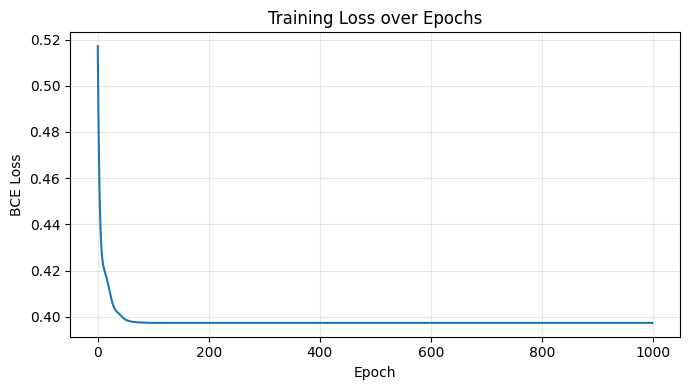

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120)
plt.show()

## Step 1.4 — Optimization Techniques & Performance Evaluation

**Optimization technique used:** L2 regularization (weight decay), applied
via the `weight_decay=0.01` argument of the Adam optimizer above. This adds
a penalty proportional to the squared magnitude of the weights to the loss,
which discourages overly large weights and helps **prevent overfitting**.

Below we evaluate the trained model's accuracy on both the training set and
the held-out test set.


In [6]:
def evaluate_accuracy(model, X_tensor, y_tensor, threshold=0.5):
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        predicted = (outputs >= threshold).float()
        accuracy = (predicted.eq(y_tensor).sum() / y_tensor.shape[0]).item()
    return accuracy, outputs, predicted

train_acc, train_outputs, train_preds = evaluate_accuracy(model, X_train_tensor, y_train_tensor)
test_acc, test_outputs, test_preds = evaluate_accuracy(model, X_test_tensor, y_test_tensor)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:     {test_acc*100:.2f}%")

Training Accuracy: 81.63%
Test Accuracy:     79.96%


## Step 1.5 — Visualize Performance: Confusion Matrix & ROC Curve

We visualize model performance on the **test set** using:
- A **confusion matrix** (with precision, recall, F1-score reported), and
- A **ROC curve** with the associated **AUC** (Area Under Curve) score.


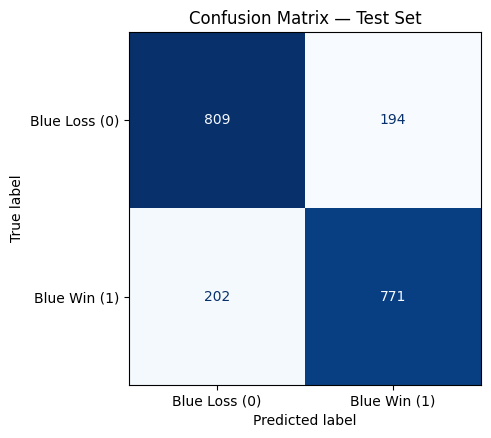

Accuracy:  0.7996
Precision: 0.7990
Recall:    0.7924
F1-score:  0.7957


In [7]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score
)

y_true = y_test_tensor.numpy().ravel()
y_pred = test_preds.numpy().ravel()
y_score = test_outputs.numpy().ravel()  # predicted probabilities

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Blue Loss (0)", "Blue Win (1)"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

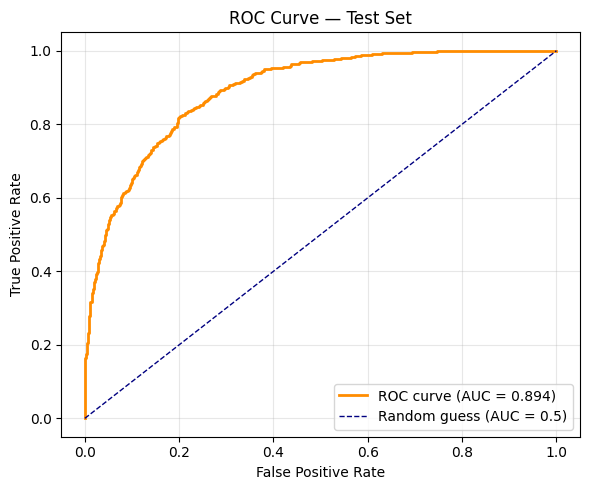

AUC Score: 0.8935


In [8]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc_score = roc_auc_score(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

## Step 1.6 — Save and Load the Trained Model

We persist the trained model's `state_dict` to disk and demonstrate loading
it back into a fresh model instance, confirming that the reloaded model
reproduces the same test accuracy.


In [9]:
MODEL_PATH = "logistic_regression_model.pth"

# Save
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

# Load into a new instance
loaded_model = LogisticRegressionModel(input_dim)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

loaded_test_acc, _, _ = evaluate_accuracy(loaded_model, X_test_tensor, y_test_tensor)
print(f"Reloaded model test accuracy: {loaded_test_acc*100:.2f}%")
assert abs(loaded_test_acc - test_acc) < 1e-6, "Loaded model accuracy mismatch!"
print("Save/load verified: accuracy matches the originally trained model.")

Model saved to logistic_regression_model.pth
Reloaded model test accuracy: 79.96%
Save/load verified: accuracy matches the originally trained model.


## Step 1.7 — Hyperparameter Tuning: Finding the Best Learning Rate

We perform a small grid search over learning rates, retraining the model
from scratch for each candidate rate, and record the resulting test
accuracy so we can identify the best-performing learning rate.


In [10]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
tuning_results = {}
tuning_epochs = 1000

for lr in learning_rates:
    torch.manual_seed(42)
    lr_model = LogisticRegressionModel(input_dim)
    lr_optimizer = torch.optim.Adam(lr_model.parameters(), lr=lr, weight_decay=0.01)
    lr_criterion = nn.BCELoss()

    for epoch in range(tuning_epochs):
        lr_model.train()
        lr_optimizer.zero_grad()
        outputs = lr_model(X_train_tensor)
        loss = lr_criterion(outputs, y_train_tensor)
        loss.backward()
        lr_optimizer.step()

    acc, _, _ = evaluate_accuracy(lr_model, X_test_tensor, y_test_tensor)
    tuning_results[lr] = acc
    print(f"Learning Rate: {lr:<6} -> Test Accuracy: {acc*100:.2f}%")

best_lr = max(tuning_results, key=tuning_results.get)
print(f"\nBest learning rate: {best_lr} (Test Accuracy: {tuning_results[best_lr]*100:.2f}%)")

Learning Rate: 0.001  -> Test Accuracy: 80.06%


Learning Rate: 0.01   -> Test Accuracy: 79.96%


Learning Rate: 0.05   -> Test Accuracy: 79.96%


Learning Rate: 0.1    -> Test Accuracy: 79.96%


Learning Rate: 0.5    -> Test Accuracy: 80.01%

Best learning rate: 0.001 (Test Accuracy: 80.06%)


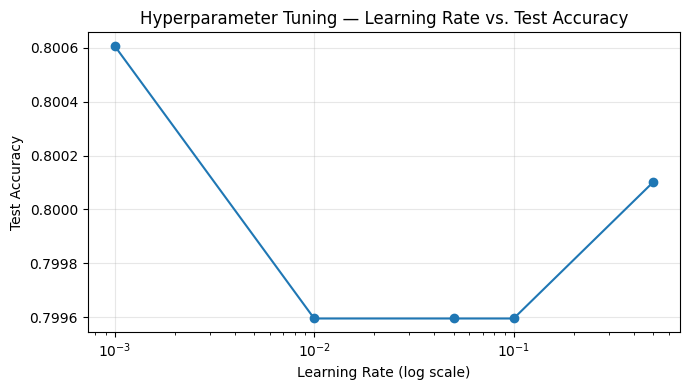

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(list(tuning_results.keys()), list(tuning_results.values()), marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Test Accuracy")
plt.title("Hyperparameter Tuning — Learning Rate vs. Test Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lr_tuning.png", dpi=120)
plt.show()

## Step 1.8 — Feature Importance

Because the model is a linear logistic regression trained on **standardized**
features, the magnitude of each learned weight directly reflects that
feature's relative importance to the prediction (larger |weight| = bigger
influence on the win/loss decision). We visualize the weights as a bar plot,
sorted by absolute value, to identify the most influential features.


              Feature    Weight  AbsWeight
0        redTotalGold -0.337411   0.337411
1       redGoldPerMin -0.337400   0.337400
2       blueTotalGold  0.335907   0.335907
3      blueGoldPerMin  0.335900   0.335900
4        blueGoldDiff  0.210603   0.210603
5         blueDragons  0.176747   0.176747
6  blueExperienceDiff  0.168255   0.168255
7            redKills -0.163315   0.163315
8          blueDeaths -0.163315   0.163315
9           blueKills  0.148013   0.148013


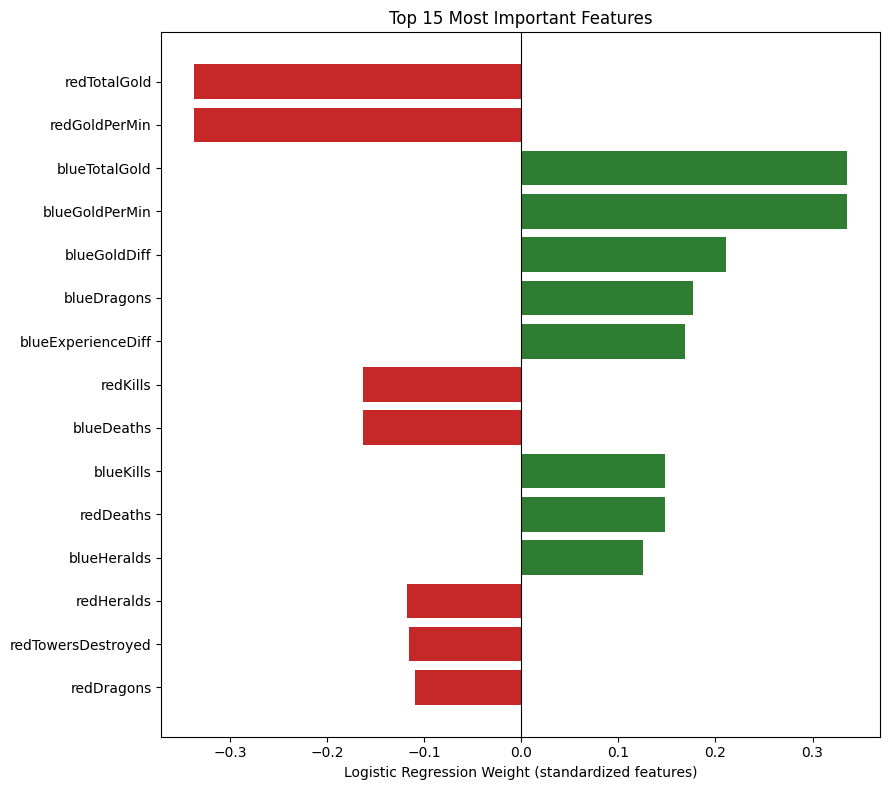


Top 3 most important features (by absolute weight):
         Feature    Weight
0   redTotalGold -0.337411
1  redGoldPerMin -0.337400
2  blueTotalGold  0.335907


In [12]:
weights = model.linear.weight.detach().numpy().flatten()
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": weights,
    "AbsWeight": np.abs(weights)
}).sort_values("AbsWeight", ascending=False).reset_index(drop=True)

print(importance_df.head(10))

plt.figure(figsize=(9, 8))
top_n = importance_df.head(15)
colors = ["#2E7D32" if w > 0 else "#C62828" for w in top_n["Weight"]]
plt.barh(top_n["Feature"][::-1], top_n["Weight"][::-1], color=colors[::-1])
plt.xlabel("Logistic Regression Weight (standardized features)")
plt.title("Top 15 Most Important Features")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

print("\nTop 3 most important features (by absolute weight):")
print(importance_df.head(3)[["Feature", "Weight"]])

## Summary

- Loaded and preprocessed the League of Legends match dataset (standardized
  features, stratified train/test split, converted to PyTorch tensors).
- Implemented and trained a logistic regression model in PyTorch using
  `nn.Linear` + `sigmoid`, `BCELoss`, and the Adam optimizer.
- Applied **L2 regularization** (`weight_decay`) as an optimization
  technique and evaluated train/test accuracy.
- Visualized performance with a **confusion matrix** and **ROC curve**
  (with AUC).
- **Saved and reloaded** the trained model, verifying consistent accuracy.
- Performed **hyperparameter tuning** over multiple learning rates to find
  the best-performing one.
- Analyzed **feature importance** via the model's learned weights to
  identify which early-game stats matter most for predicting match outcome.
